# CIFAR-10 图像分类完整流程

以 CIFAR-10 为例，展示真实图片分类项目的完整结构：读取标签表 → 划分训练/验证集 → 自定义 Dataset → 数据增强 → CNN 分类器 → 训练 → 生成提交文件。

## 学习目标
- 理解"CSV 标签 + 图片文件夹"的数据组织方式。
- 区分为何训练用随机增强而验证/测试用确定性预处理。
- 掌握自定义 `Dataset` 的三个关键方法：`__init__`、`__len__`、`__getitem__`。
- 学会将模型预测结果还原成提交所需的 CSV 格式。

## 导入图像分类所需模块

PyTorch 负责模型训练，torchvision 负责图像变换，pandas 管理标签表，PIL 读取图片。四者分工明确。

In [1]:
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize, ConvertImageDtype, RandomRotation, RandomHorizontalFlip
)
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import gc

import torch
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 复用项目训练器

`get_trainer()` 将项目根目录加入 `sys.path`，导入统一封装的 `TorchTrainer`。这样 notebook 里不需要重复写训练循环代码，专注于数据读取和模型定义。

In [2]:
def get_trainer():
    import sys
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    from base import TorchTrainer
    return TorchTrainer

## 读取标签并划分数据

CIFAR-10 的训练图片标签来自 CSV 文件 `trainLabels.csv`。测试集没有真实标签，仅用于最终预测。

验证集必须从训练数据中划分出来，因为测试集不能用来调参——否则无法评估泛化能力。

In [3]:
DATA_DIR = Path('../data/cifar-10')
train_labels = pd.read_csv(DATA_DIR / 'trainLabels.csv')
test_labels = pd.read_csv(DATA_DIR / 'sampleSubmission.csv')
train_folder = DATA_DIR / 'train'
test_folder = DATA_DIR / 'test'

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


def get_image_path(labels, folder):
    path_labels = []
    for index, row in labels.iterrows():
        image_id = row['id']
        image_label = row['label']
        image_path = folder / f"{image_id}.png"
        path_labels.append((image_path, image_label))
    return path_labels


train_image_paths = get_image_path(train_labels, train_folder)
test_image_paths = get_image_path(test_labels, test_folder)

ratio = 0.9
train_df = pd.DataFrame(
    train_image_paths[:int(len(train_image_paths) * ratio)],
    columns=['image_path', 'label'])
val_df = pd.DataFrame(
    train_image_paths[int(len(train_image_paths) * ratio):],
    columns=['image_path', 'label'])
test_df = pd.DataFrame(test_image_paths, columns=['image_path', 'label'])

## 自定义 Dataset 与数据增强

`Cifar10Dataset` 的职责：根据索引找到图片文件，读取并应用 transform，返回 `(image, label)`。

**训练阶段**使用随机增强（旋转、翻转等），扩充数据多样性；**验证/测试阶段**使用确定性预处理，保证评估结果可复现。

In [4]:
class Cifar10Dataset(Dataset):
    df_map = {
        'train': train_df,
        'val': val_df,
        'test': test_df
    }

    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, model="train", transform=None):
        self.data = self.df_map[model]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, label = self.data.iloc[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.label_to_idx[label]
        return image, label


IMG_SIZE = 32


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    Cifar10Dataset(model='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))


# 图像增强可以增加训练数据的多样性，帮助模型更好地泛化，从而提高模型的性能和鲁棒性。
# 1. 随机旋转图像：通过随机旋转图像，可以模拟不同的拍摄角度和姿态，使模型更好地适应各种视角。
# 2. 随机水平翻转图像：通过随机水平翻转图像，可以模拟左右对称的物体，使模型更好地适应不同的方向和姿态。
# 3. 随机裁剪图像：通过随机裁剪图像，可以模拟不同的物体位置和大小，使模型更好地适应各种场景和物体尺寸。
# 4. 随机调整图像亮度、对比度和饱和度：通过随机调整图像的亮度、对比度和饱和度，可以模拟不同的光照条件和环境，使模型更好地适应各种光照变化。
# 5. 随机添加噪声：通过随机添加噪声，可以模拟不同的图像质量和干扰，使模型更好地适应各种图像质量和干扰情况。
transform_train = Compose([
    Resize(IMG_SIZE),
    # 随机旋转图像，旋转角度在-40到40度之间
    RandomRotation(40),
    # 随机水平翻转图像，翻转概率为0.5
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

transform_eval = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

Computing mean/std: 100%|██████████| 704/704 [03:40<00:00,  3.19it/s]


## 构造 DataLoader

关键规则：
- **训练集** `shuffle=True`：每个 epoch 随机打乱。
- **验证/测试集** `shuffle=False`：保持顺序不变，预测结果才能和样本 id 对齐。

In [5]:
train_ds = Cifar10Dataset(model='train', transform=transform_train)
val_ds = Cifar10Dataset(model='val', transform=transform_eval)
test_ds = Cifar10Dataset(model='test', transform=transform_eval)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## 定义 CNN 分类器

三层卷积组逐步提取特征：每组的通道数递增（128→256→512），空间尺寸通过池化逐步减小。最后用全局平均池化 + 全连接映射到 10 个类别。

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(
                in_channels=3, out_channels=128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(
                in_channels=128, out_channels=128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(
                in_channels=128, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(
                in_channels=256, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(
                in_channels=256, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.Conv2d(
                in_channels=512, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    
print(sum(p.numel() for p in CNN().parameters()))

4647178


## 配置训练策略

- **优化器 Adam**：自适应学习率，适合大多数场景。
- **损失函数 CrossEntropyLoss**：多分类标准选择，内部包含 softmax。
- **学习率调度器 ReduceLROnPlateau**：验证损失停滞时自动降低学习率，帮助模型更精细地收敛。

Epoch 1/20 | train_loss=1.4866 | train_acc=0.4561 | train_balanced_acc=0.4561 | train_f1_macro=0.4513 | val_loss=1.2124 | val_acc=0.5732 | val_balanced_acc=0.5710 | val_f1_macro=0.5604 | lr=0.0010 | epoch_seconds=54.8014


Epoch 2/20 | train_loss=1.1040 | train_acc=0.6070 | train_balanced_acc=0.6070 | train_f1_macro=0.6052 | val_loss=0.9603 | val_acc=0.6880 | val_balanced_acc=0.6883 | val_f1_macro=0.6824 | lr=0.0010 | epoch_seconds=35.4111


Epoch 3/20 | train_loss=0.8977 | train_acc=0.6855 | train_balanced_acc=0.6855 | train_f1_macro=0.6847 | val_loss=0.7322 | val_acc=0.7508 | val_balanced_acc=0.7501 | val_f1_macro=0.7514 | lr=0.0010 | epoch_seconds=35.4367


Epoch 4/20 | train_loss=0.7611 | train_acc=0.7365 | train_balanced_acc=0.7365 | train_f1_macro=0.7359 | val_loss=0.6016 | val_acc=0.7892 | val_balanced_acc=0.7889 | val_f1_macro=0.7876 | lr=0.0010 | epoch_seconds=34.4718


Epoch 5/20 | train_loss=0.6615 | train_acc=0.7694 | train_balanced_acc=0.7693 | train_f1_macro=0.7688 | val_loss=0.5534 | val_acc=0.8124 | val_balanced_acc=0.8129 | val_f1_macro=0.8117 | lr=0.0010 | epoch_seconds=34.1870


...

Epoch 16/20 | train_loss=0.2861 | train_acc=0.9010 | train_balanced_acc=0.9010 | train_f1_macro=0.9009 | val_loss=0.3962 | val_acc=0.8712 | val_balanced_acc=0.8714 | val_f1_macro=0.8717 | lr=0.0010 | epoch_seconds=35.0797


Epoch 17/20 | train_loss=0.2728 | train_acc=0.9046 | train_balanced_acc=0.9045 | train_f1_macro=0.9045 | val_loss=0.3805 | val_acc=0.8798 | val_balanced_acc=0.8801 | val_f1_macro=0.8801 | lr=0.0010 | epoch_seconds=35.1821


Epoch 18/20 | train_loss=0.2568 | train_acc=0.9098 | train_balanced_acc=0.9098 | train_f1_macro=0.9097 | val_loss=0.3511 | val_acc=0.8854 | val_balanced_acc=0.8854 | val_f1_macro=0.8859 | lr=0.0010 | epoch_seconds=35.0369


Epoch 19/20 | train_loss=0.2497 | train_acc=0.9121 | train_balanced_acc=0.9121 | train_f1_macro=0.9120 | val_loss=0.4084 | val_acc=0.8772 | val_balanced_acc=0.8771 | val_f1_macro=0.8778 | lr=0.0010 | epoch_seconds=34.7630


Epoch 20/20 | train_loss=0.2258 | train_acc=0.9208 | train_balanced_acc=0.9208 | train_f1_macro=0.9207 | val_loss=0.3794 | val_acc=0.8876 | val_balanced_acc=0.8879 | val_f1_macro=0.8876 | lr=0.0010 | epoch_seconds=34.9665


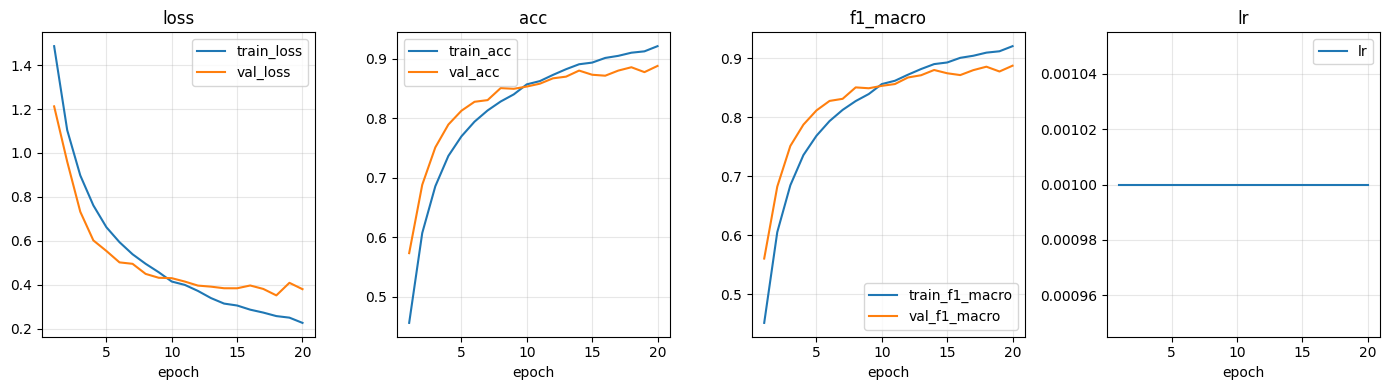

In [7]:
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

trainer = get_trainer()(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()

# test_log = trainer.evaluate(test_loader)
# print(f"Final test accuracy: {test_log['acc']:.4f}")

## 生成预测结果

训练完成后，对测试集做推理。实际提交时需要把模型输出的类别编号转回类别名称（如 `0 → airplane`），并按 `id,label` 格式保存为 CSV。

In [ ]:
res = trainer.predict(test_loader)
res_df = pd.DataFrame(res, columns=['id', 'label'])
res_df.to_csv('submission.csv', index=False)
res_df.head()

In [22]:
# 保存提交文件: id,label
_, y_pred, _ = res

submission = test_labels[['id']].copy()
submission['label'] = [class_names[int(i)] for i in y_pred]

out_path = DATA_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)

print('saved:', out_path)
print(submission.head())

saved: ..\data\cifar-10\submission.csv
   id       label
0   1    airplane
1   2    airplane
2   3  automobile
3   4        ship
4   5    airplane
